In [2]:
import pandas as pd
import torch
import numpy as np

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

#### 2. Load Saved Model

In [3]:
model = DistilBertForSequenceClassification.from_pretrained(
    "../resume_classifier"
)

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "../resume_classifier"
)

print("Model Loaded Successfully")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model Loaded Successfully


#### 3. Load Label Encoder

In [4]:
encoder = joblib.load(
    "../artifacts/label_encoder.pkl"
)

print(len(encoder.classes_))

99


#### 4. Load Dataset

In [9]:
import pandas as pd

df = pd.read_csv("../documents/preprocessed_resume_dataset.csv")

df.head()
print(df.shape)

(10035, 6)


#### 5. Encode Labels

In [10]:
df["label"] = encoder.transform(
    df["category"]
)

#### 6.Create Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned_text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

print(X_test.shape)

(2007,)


#### 7. Predict Test Set

In [12]:
predictions = []

for text in X_test:

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    )

    with torch.no_grad():
        outputs = model(**inputs)

    pred = outputs.logits.argmax().item()

    predictions.append(pred)

print("Prediction Completed")

Prediction Completed


#### 8. Accuracy

In [13]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.6696562032884903


#### 9. Classification Report

In [14]:
report = classification_report(
    y_test,
    predictions,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        79
           1       0.68      0.75      0.71        20
           2       0.84      0.81      0.82        75
           3       0.89      0.89      0.89        18
           4       0.74      0.74      0.74        58
           5       0.50      0.12      0.20         8
           6       0.76      0.96      0.85        26
           7       0.64      0.83      0.72        30
           8       0.00      0.00      0.00        11
           9       0.67      0.90      0.77        39
          10       0.00      0.00      0.00        16
          11       0.81      0.80      0.80        54
          12       0.56      0.78      0.65        18
          13       0.82      0.96      0.89        28
          14       0.00      0.00      0.00         6
          15       0.63      0.92      0.75        13
          16       0.78      0.81      0.79        26
          17       0.50    

#### 10 . Confusion Matrix

In [15]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[64  7  1 ...  0  0  0]
 [ 5 15  0 ...  0  0  0]
 [ 1  0 61 ...  0  0  0]
 ...
 [ 0  0  0 ...  4  0  2]
 [ 0  0  0 ...  0 19  0]
 [ 0  0  0 ...  0  0  8]]


#### 11. Plot Confusion Matrix

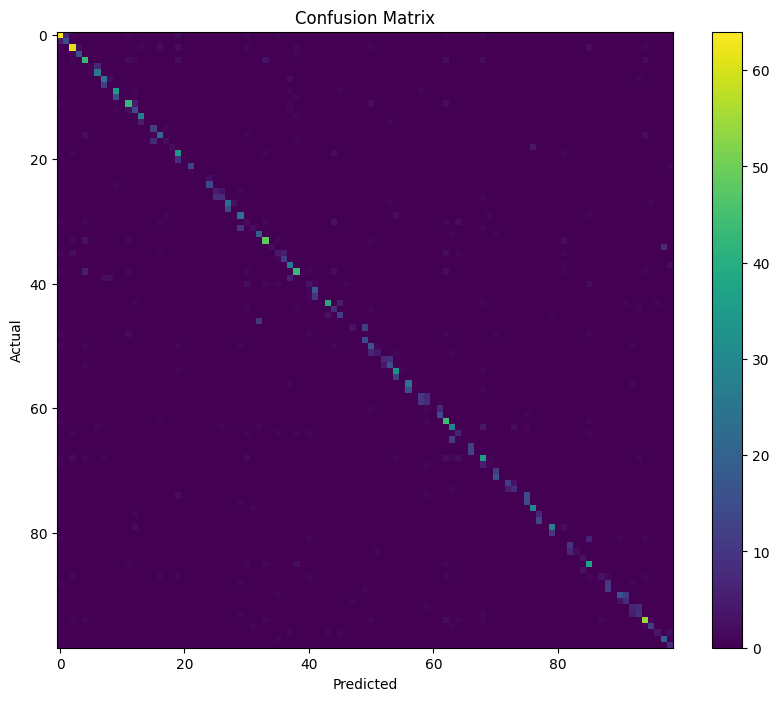

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#### 12. Save Evaluation Report

In [17]:
with open("evaluation_report.txt", "w") as f:

    f.write(f"Accuracy: {accuracy}\n\n")

    f.write(report)

print("Evaluation Report Saved")

Evaluation Report Saved
